# Гипотеза 3 — Для каких типов рядов какая трансформация полезнее?

**Датасет:** M4 Monthly, 200 рядов, горизонт прогноза = 18 шагов  
**Модели:** Naive, SeasonalNaive, Mean, Median, AutoTheta, AutoETS, CatBoost (Direct)  
**Трансформации:** none · log1p · boxcox · diff  

---
1. Импорты и загрузка данных
2. Характеристики выборки
3. Подбор числа кластеров (силуэт + локоть)
4. Описание кластеров
5. Примеры рядов и эффект трансформаций
6. Глобальные метрики
7. Лучшая трансформация по кластерам
8. Аномалия CatBoost + boxcox
9. Детальное сравнение по кластерам
10. Выводы

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from config import DATA_CONFIG, CLUSTERING_CONFIG, TRANSFORM_CONFIG
import src.data as data_module
import src.clustering as clustering_module
import src.transforms as transforms_module

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})
C = sns.color_palette('tab10')
TRANSFORMS = TRANSFORM_CONFIG['candidates']
PALETTE = {'none': C[0], 'log1p': C[1], 'boxcox': C[2], 'diff': C[3]}
RESULTS_DIR = 'results'

## 1. Загрузка данных

In [3]:
raw = data_module.load_m4_data(frequency=DATA_CONFIG['frequency'])
sampled = data_module.sample_series(
    raw, n_samples=DATA_CONFIG['sample_size'],
    random_seed=DATA_CONFIG['random_seed']
)
train_df, test_df = data_module.train_test_split(
    sampled, horizon=DATA_CONFIG['forecast_horizon']
)
train_list, uid_list = data_module.series_to_list(train_df)
test_list, _ = data_module.series_to_list(test_df)

[data] Загружено M4 monthly: 48000 рядов


## 2. Характеристики выборки

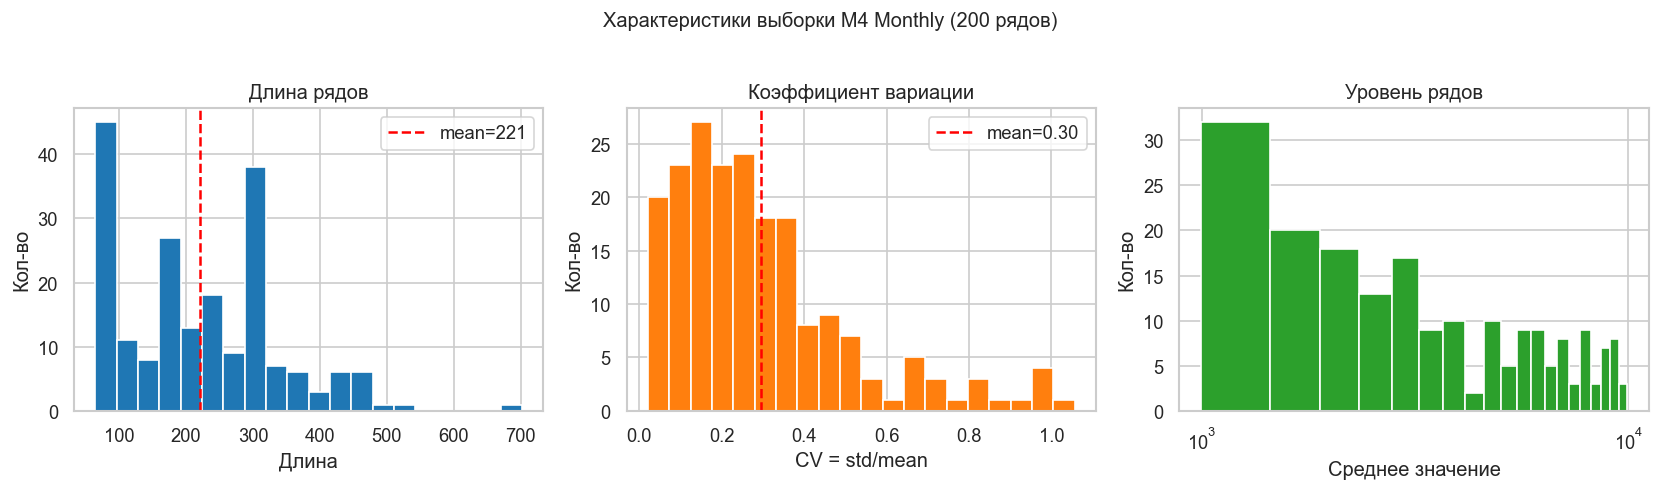

In [4]:
lengths = [len(y) for y in train_list]
cvs     = [np.std(y) / (np.mean(y) + 1e-6) for y in train_list]
levels  = [np.mean(y) for y in train_list]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(lengths, bins=20, color=C[0], edgecolor='white')
axes[0].axvline(np.mean(lengths), color='red', ls='--', label=f'mean={np.mean(lengths):.0f}')
axes[0].set(title='Длина рядов', xlabel='Длина', ylabel='Кол-во')
axes[0].legend()

axes[1].hist(cvs, bins=20, color=C[1], edgecolor='white')
axes[1].axvline(np.mean(cvs), color='red', ls='--', label=f'mean={np.mean(cvs):.2f}')
axes[1].set(title='Коэффициент вариации', xlabel='CV = std/mean', ylabel='Кол-во')
axes[1].legend()

axes[2].hist(levels, bins=20, color=C[2], edgecolor='white')
axes[2].set_xscale('log')
axes[2].set(title='Уровень рядов', xlabel='Среднее значение', ylabel='Кол-во')

plt.suptitle('Характеристики выборки M4 Monthly (200 рядов)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('series_characteristics.png', bbox_inches='tight')
plt.show()


## 3. Подбор числа кластеров

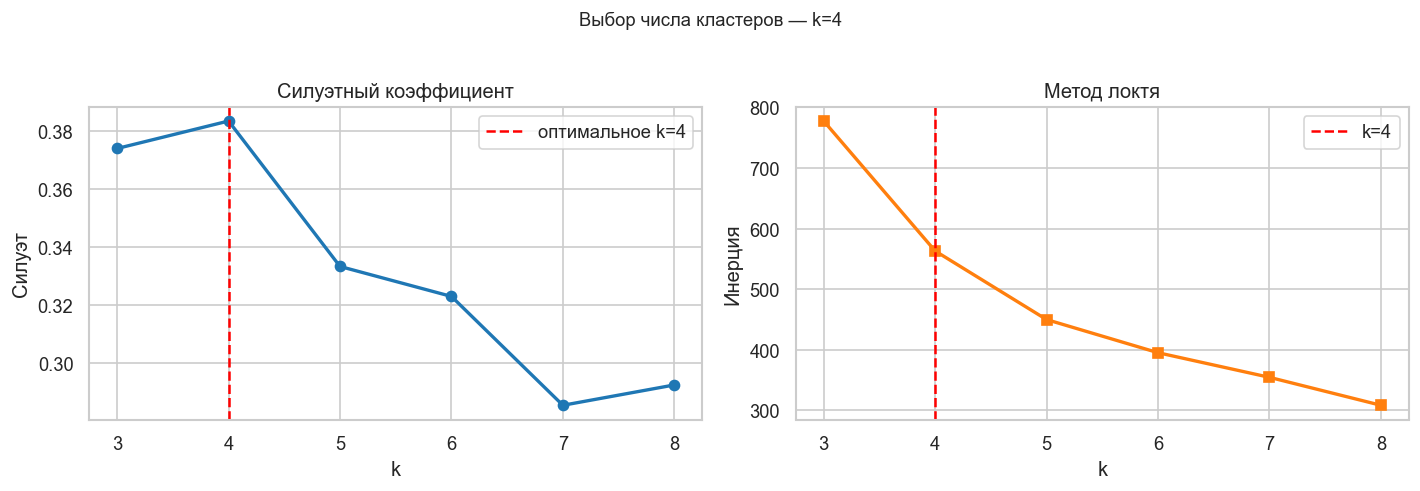

In [7]:
feat_df = clustering_module.extract_features(train_list)
X_sc    = StandardScaler().fit_transform(feat_df)

k_range    = range(CLUSTERING_CONFIG['k_min'], CLUSTERING_CONFIG['k_max'] + 1)
sil_scores = []
inertias   = []
for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init='auto')
    lab = km.fit_predict(X_sc)
    sil_scores.append(silhouette_score(X_sc, lab))
    inertias.append(km.inertia_)

best_k = list(k_range)[np.argmax(sil_scores)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), sil_scores, marker='o', color=C[0], lw=2)
axes[0].axvline(best_k, ls='--', color='red', label=f'оптимальное k={best_k}')
axes[0].set(title='Силуэтный коэффициент', xlabel='k', ylabel='Силуэт')
axes[0].legend()

axes[1].plot(list(k_range), inertias, marker='s', color=C[1], lw=2)
axes[1].axvline(best_k, ls='--', color='red', label=f'k={best_k}')
axes[1].set(title='Метод локтя', xlabel='k', ylabel='Инерция')
axes[1].legend()

plt.suptitle(f'Выбор числа кластеров — k={best_k}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('silhouette_elbow.png', bbox_inches='tight')
plt.show()

## 4. Описание кластеров

In [9]:
labels, score, _ = clustering_module.cluster_series(feat_df, n_clusters=best_k)
feat_df['cluster'] = labels

cluster_stats = feat_df.groupby('cluster').agg(
    n=('mean','count'), mean_level=('mean','mean'),
    mean_cv=('cv','mean'), mean_skew=('skew','mean'),
    mean_kurt=('kurt','mean'), mean_trend=('trend','mean')
).round(3)

display(cluster_stats)

[clustering] k = 4


,n,mean_level,mean_cv,mean_skew,mean_kurt,mean_trend
cluster,,,,,,
0,138,3535.984,0.198,0.146,-0.246,2.264
1,19,6697.186,0.358,0.427,-0.615,-70.158
2,40,5017.105,0.563,0.787,0.430,34.531
3,3,3570.970,0.818,5.214,36.783,6.432


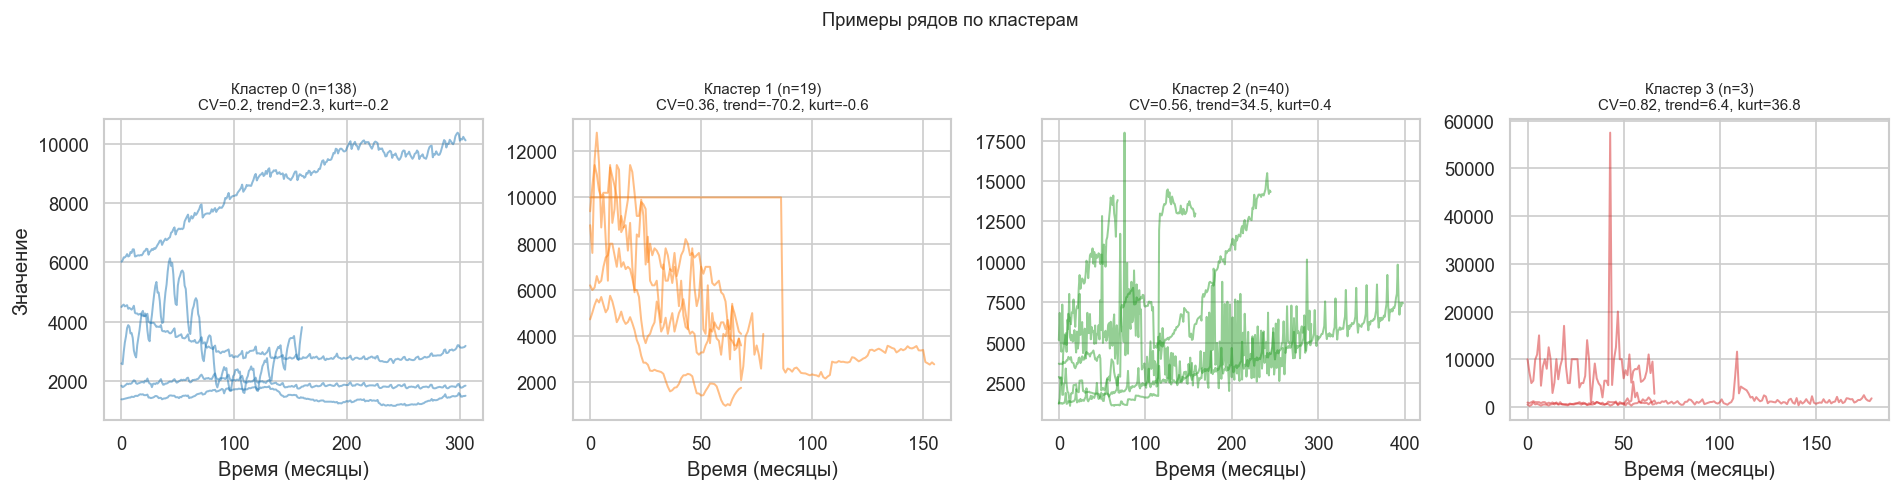

In [11]:
# Примеры рядов по кластерам
fig, axes = plt.subplots(1, best_k, figsize=(4 * best_k, 4), sharey=False)
if best_k == 1:
    axes = [axes]

for c in range(best_k):
    idxs = np.where(labels == c)[0][:5]
    for idx in idxs:
        axes[c].plot(train_list[idx], alpha=0.5, linewidth=1.2, color=C[c])
    cv  = round(cluster_stats.loc[c, 'mean_cv'], 2)
    tr  = round(cluster_stats.loc[c, 'mean_trend'], 1)
    ku  = round(cluster_stats.loc[c, 'mean_kurt'], 1)
    n_c = int(cluster_stats.loc[c, 'n'])
    axes[c].set_title(f'Кластер {c} (n={n_c})\nCV={cv}, trend={tr}, kurt={ku}', fontsize=9)
    axes[c].set_xlabel('Время (месяцы)')
    if c == 0:
        axes[c].set_ylabel('Значение')

plt.suptitle('Примеры рядов по кластерам', y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig('cluster_samples.png', bbox_inches='tight')
plt.show()

## 5. Эффект трансформаций

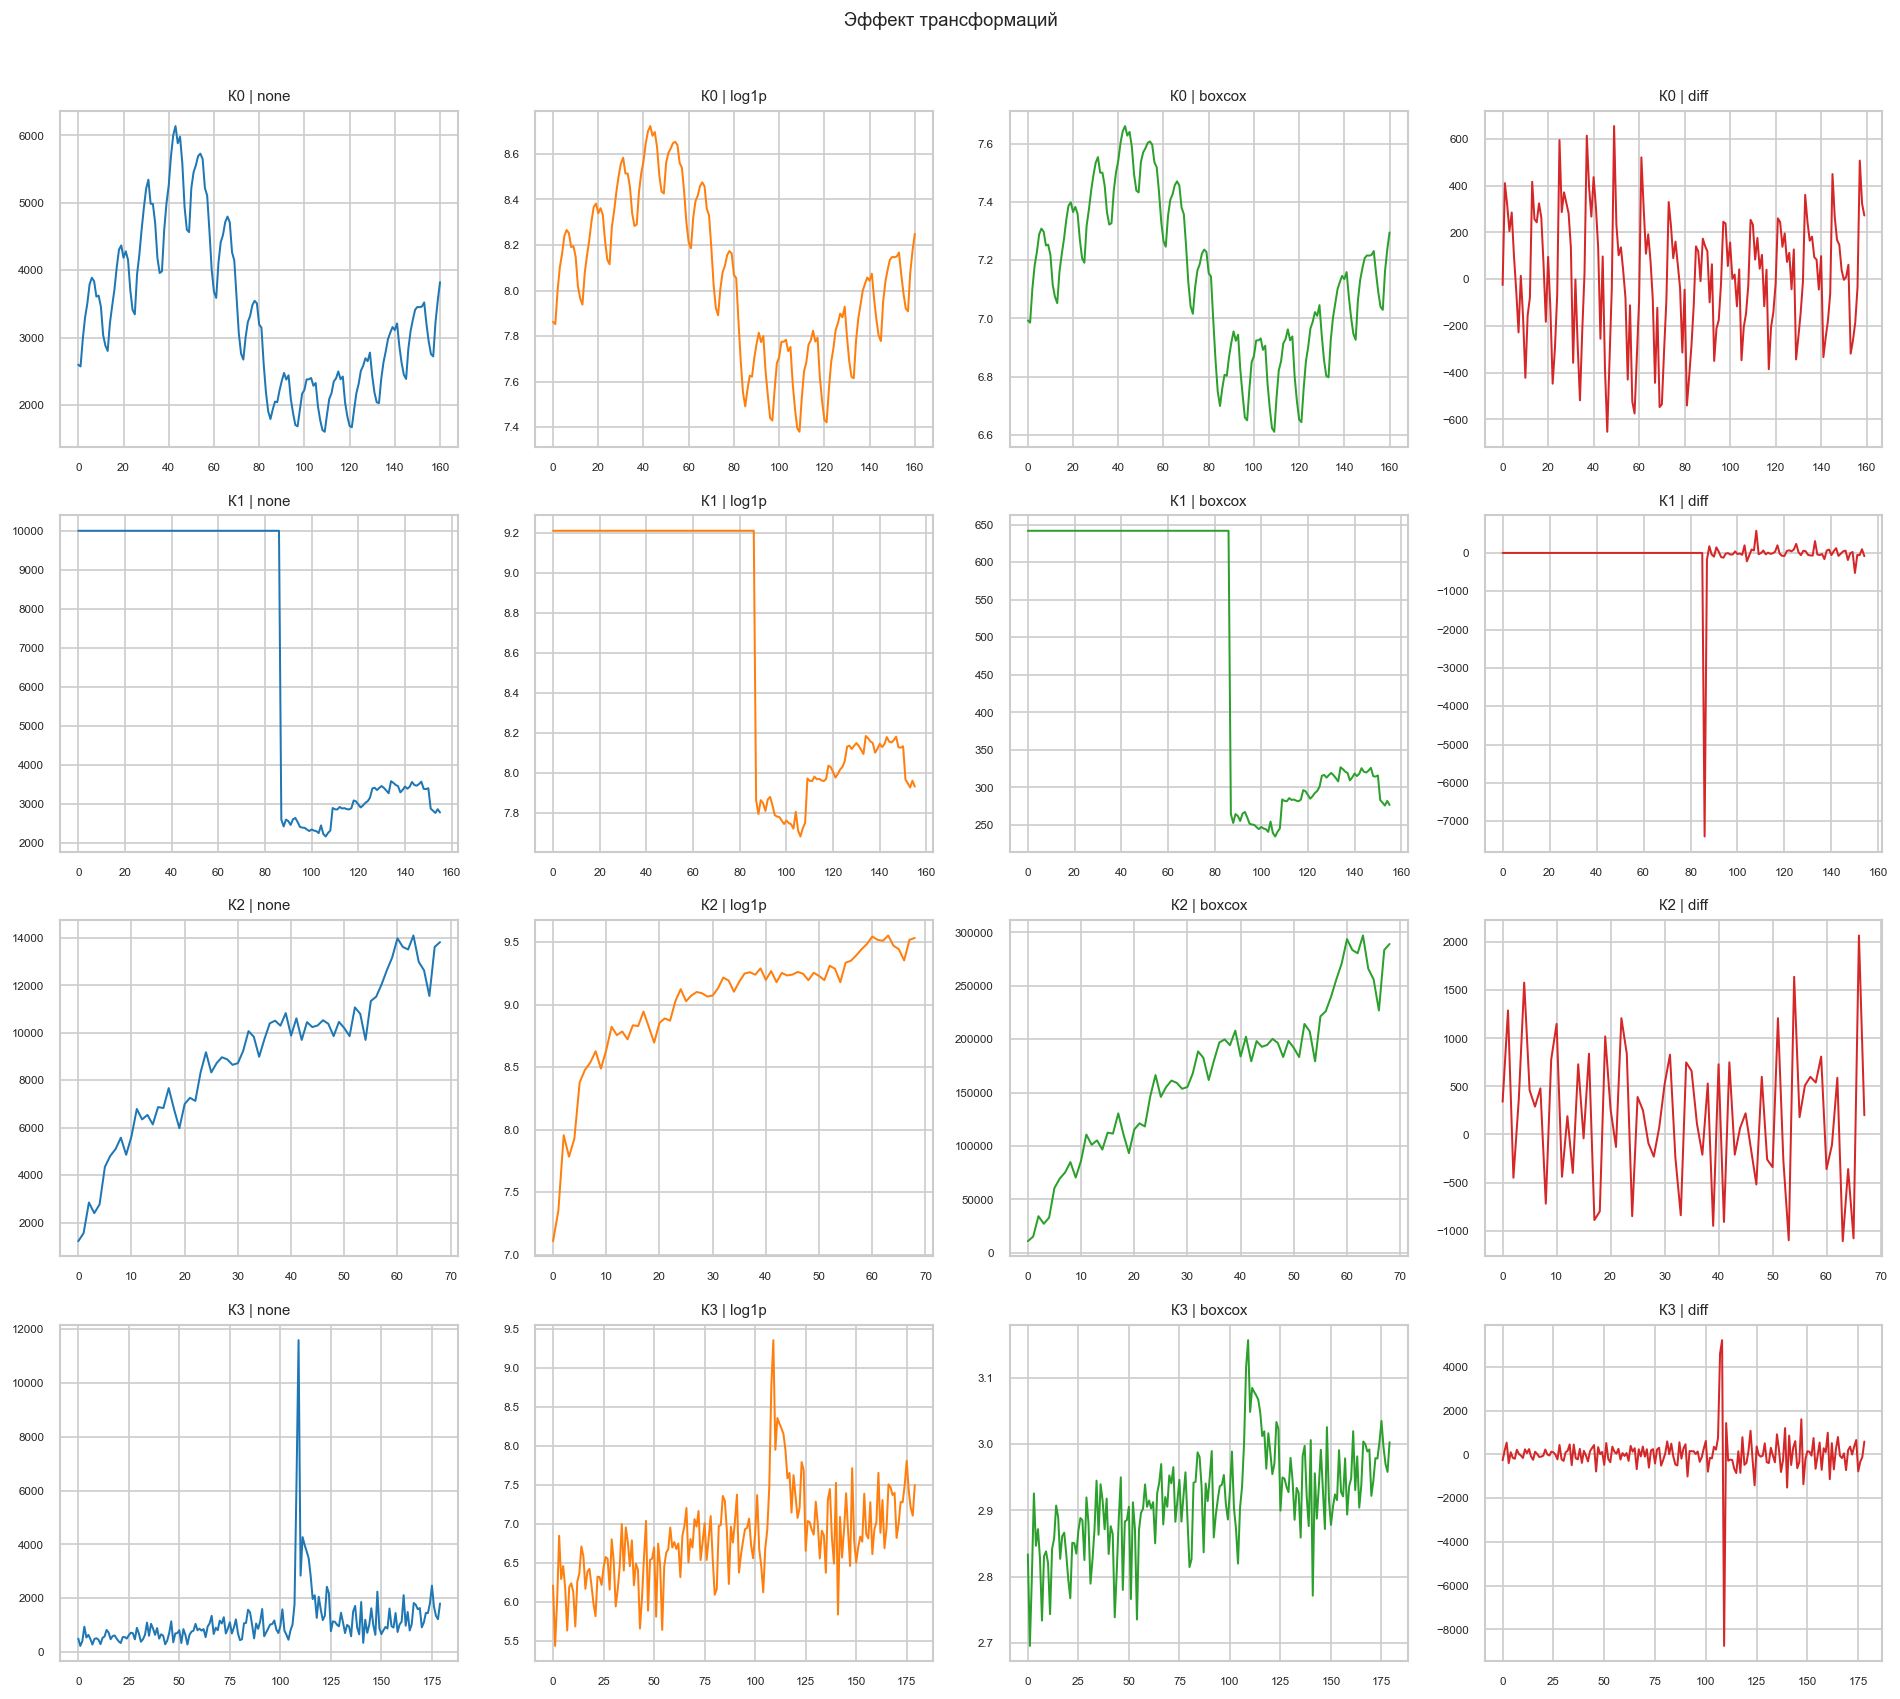

In [12]:

fig, axes = plt.subplots(best_k, len(TRANSFORMS),
                         figsize=(4 * len(TRANSFORMS), 3.5 * best_k))
if best_k == 1:
    axes = [axes]

for c in range(best_k):
    idx   = np.where(labels == c)[0][0]
    y_orig = train_list[idx].copy()
    for j, kind in enumerate(TRANSFORMS):
        y_tr, _ = transforms_module.apply_transform(y_orig.copy(), kind)
        axes[c][j].plot(y_tr, color=PALETTE[kind], lw=1.2)
        axes[c][j].set_title(f'К{c} | {kind}', fontsize=9)
        axes[c][j].tick_params(labelsize=7)

plt.suptitle('Эффект трансформаций', y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig('transform_effects.png', bbox_inches='tight')
plt.show()

## 6. Глобальные метрики

In [14]:
summary = pd.read_csv(f'summary.csv')
display(summary.round(4))

,transform,model,MAE,RMSE,MAPE,sMAPE,MASE
0,none,naive,602.9566,743.5720,15.8221,13.5324,1.2284
1,none,seasonal_naive,629.1012,765.0276,18.8716,14.7285,1.2661
2,none,mean,1557.0480,1651.1128,39.6577,34.0917,4.2399
3,none,median,1651.6782,1746.1228,40.1326,36.6592,4.4318
4,none,AutoTheta,516.3520,636.4816,13.9910,12.1043,0.9808
5,none,AutoETS,513.2482,643.4906,14.4637,11.8337,0.9228
6,none,catboost,670.4660,809.2268,18.6872,14.7775,1.4892
7,log1p,naive,602.9566,743.5720,15.8221,13.5324,1.2284
8,log1p,seasonal_naive,629.1012,765.0276,18.8716,14.7285,1.2661
9,log1p,mean,1557.0480,1651.1128,39.6577,34.0917,4.2399


/var/folders/1c/8mxq1q093kj6nwgly1cnbrfr0000gp/T/ipykernel_39254/2858013568.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=9)


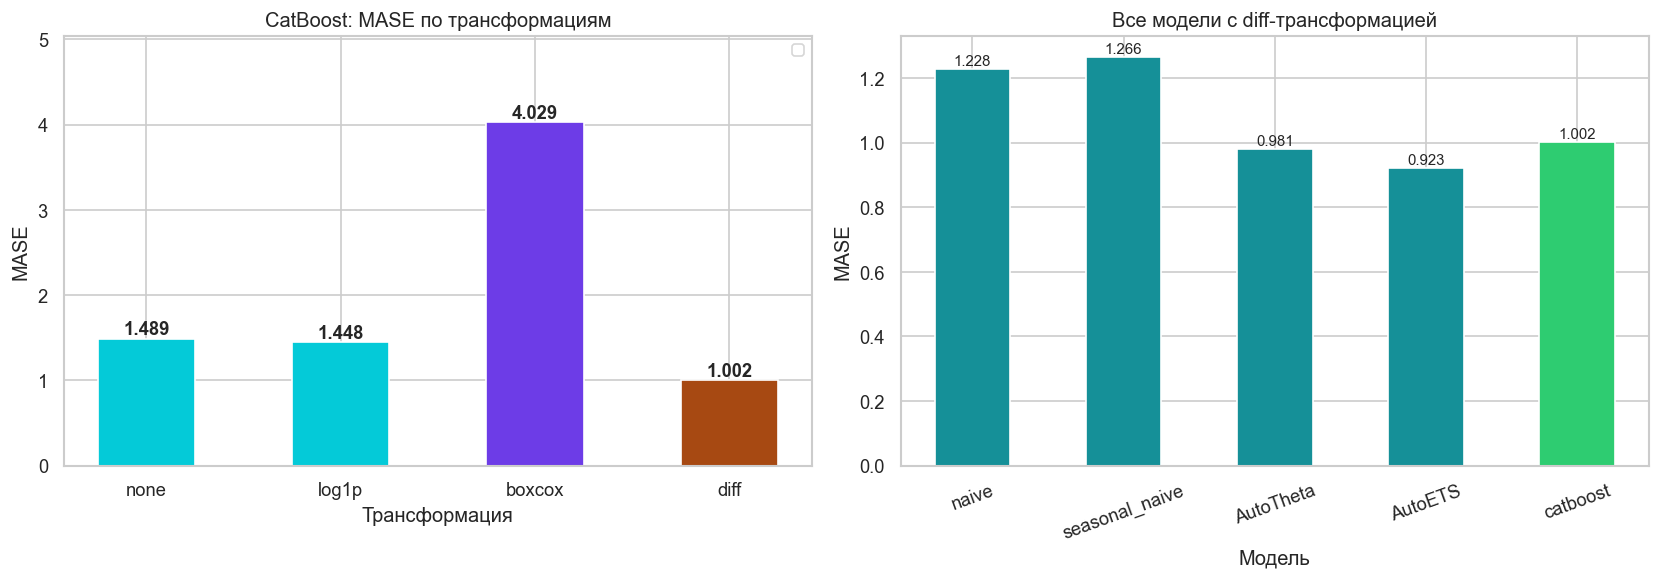

In [17]:
# MASE CatBoost по трансформациям с линиями бейзлайнов
cb = summary[summary['model'] == 'catboost'][['transform','MASE']].set_index('transform')
naive_mase = summary[(summary['model']=='naive') & (summary['transform']=='none')]['MASE'].values[0]
theta_mase = summary[(summary['model']=='AutoTheta') & (summary['transform']=='none')]['MASE'].values[0]
ets_mase   = summary[(summary['model']=='AutoETS')   & (summary['transform']=='none')]['MASE'].values[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Левый: CatBoost по трансформациям
colors_bar = ["#6d3ce7" if t == 'boxcox' else
              "#A74912" if t == 'diff'   else "#04cad8"
              for t in cb.index]
bars = axes[0].bar(cb.index, cb['MASE'], color=colors_bar, edgecolor='white', width=0.5)
for bar, val in zip(bars, cb['MASE']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set(title='CatBoost: MASE по трансформациям',
            xlabel='Трансформация', ylabel='MASE')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, max(cb['MASE']) * 1.25)

# Правый: все модели на diff
MODELS_ORDER = ['naive','seasonal_naive','AutoTheta','AutoETS','catboost']
diff_data = (summary[summary['transform']=='diff']
             .set_index('model')
             .reindex([m for m in MODELS_ORDER if m in summary['model'].values]))
mc = ['#2ecc71' if m == 'catboost' else "#159098" for m in diff_data.index]
bars2 = axes[1].bar(diff_data.index, diff_data['MASE'], color=mc, edgecolor='white', width=0.5)
for bar, val in zip(bars2, diff_data['MASE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=9)
axes[1].set(title='Все модели с diff-трансформацией',
            xlabel='Модель', ylabel='MASE')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('global_mase.png', bbox_inches='tight')
plt.show()

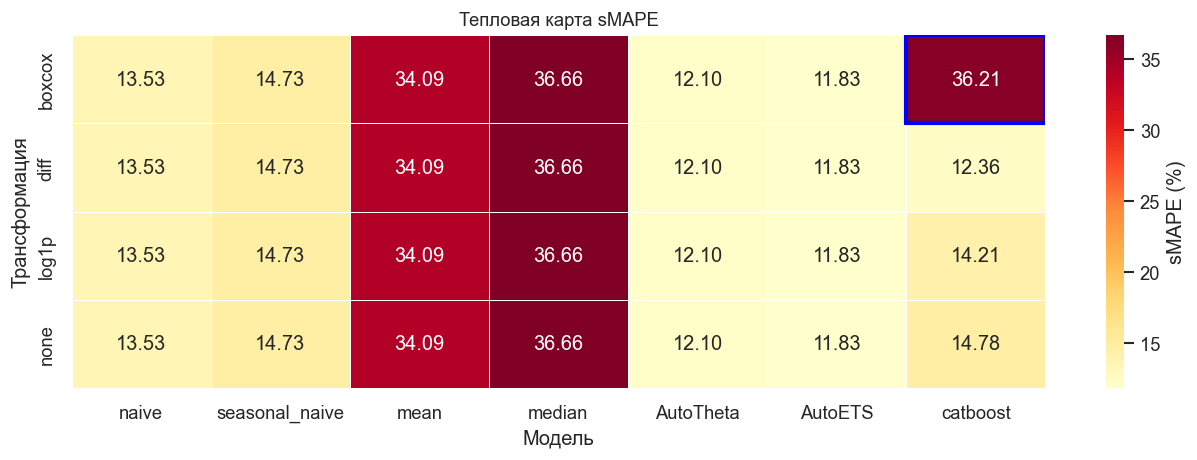

In [19]:
# Тепловая карта sMAPE с выделением аномалии boxcox
heat = summary.pivot(index='transform', columns='model', values='sMAPE')
col_order = [c for c in ['naive','seasonal_naive','mean','median','AutoTheta','AutoETS','catboost']
             if c in heat.columns]
heat = heat[col_order]

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'sMAPE (%)'})
ax.set_title('Тепловая карта sMAPE', fontsize=11)
ax.set_xlabel('Модель')
ax.set_ylabel('Трансформация')

if 'boxcox' in list(heat.index) and 'catboost' in col_order:
    box_row = list(heat.index).index('boxcox')
    box_col = col_order.index('catboost')
    ax.add_patch(plt.Rectangle((box_col, box_row), 1, 1,
                 fill=False, edgecolor='blue', lw=2.5))

plt.tight_layout()
plt.savefig('heatmap_smape.png', bbox_inches='tight')
plt.show()

## 7. Лучшая трансформация для CatBoost по кластерам

In [26]:
bd         = pd.read_csv(f'cluster_breakdown.csv')
conclusion = pd.read_csv(f'conclusion.csv')
cb_bd = bd[bd['model'] == 'catboost'].copy()

mase_pivot  = cb_bd.pivot(index='cluster', columns='transform', values='MASE')
smape_pivot = cb_bd.pivot(index='cluster', columns='transform', values='sMAPE')

n_per_cluster = conclusion.set_index('cluster')['n_series'].to_dict()

feat_df_cl    = clustering_module.extract_features(train_list)
feat_df_cl['cluster'] = labels
cluster_stats_cl = feat_df_cl.groupby('cluster')[['cv','trend','kurt']].mean().round(3)

result_table = mase_pivot.copy()
result_table.insert(0, 'n',     [n_per_cluster.get(c, '?') for c in result_table.index])
result_table.insert(1, 'CV',    cluster_stats_cl['cv'])
result_table.insert(2, 'trend', cluster_stats_cl['trend'])
result_table['Лучшая (MASE)']  = mase_pivot.idxmin(axis=1)
result_table['Лучшая (sMAPE)'] = smape_pivot.idxmin(axis=1)

metric_cols = [c for c in ['none','log1p','boxcox','diff']
               if c in result_table.columns]


print('MASE CatBoost по кластерам:')
display(
    result_table.round(3).style.format({c: '{:.3f}' for c in metric_cols})
)

MASE CatBoost по кластерам:


transform,n,CV,trend,boxcox,diff,log1p,none,Лучшая (MASE),Лучшая (sMAPE)
cluster,,,,,,,,,
0,138,0.198000,2.264000,4.973,0.990,1.480,1.466,diff,diff
1,40,0.358000,-70.158000,2.510,1.195,1.702,1.956,diff,diff
2,19,0.563000,34.531000,0.858,0.673,0.807,0.815,diff,diff
3,3,0.818000,6.432000,0.968,1.068,0.628,0.592,none,none


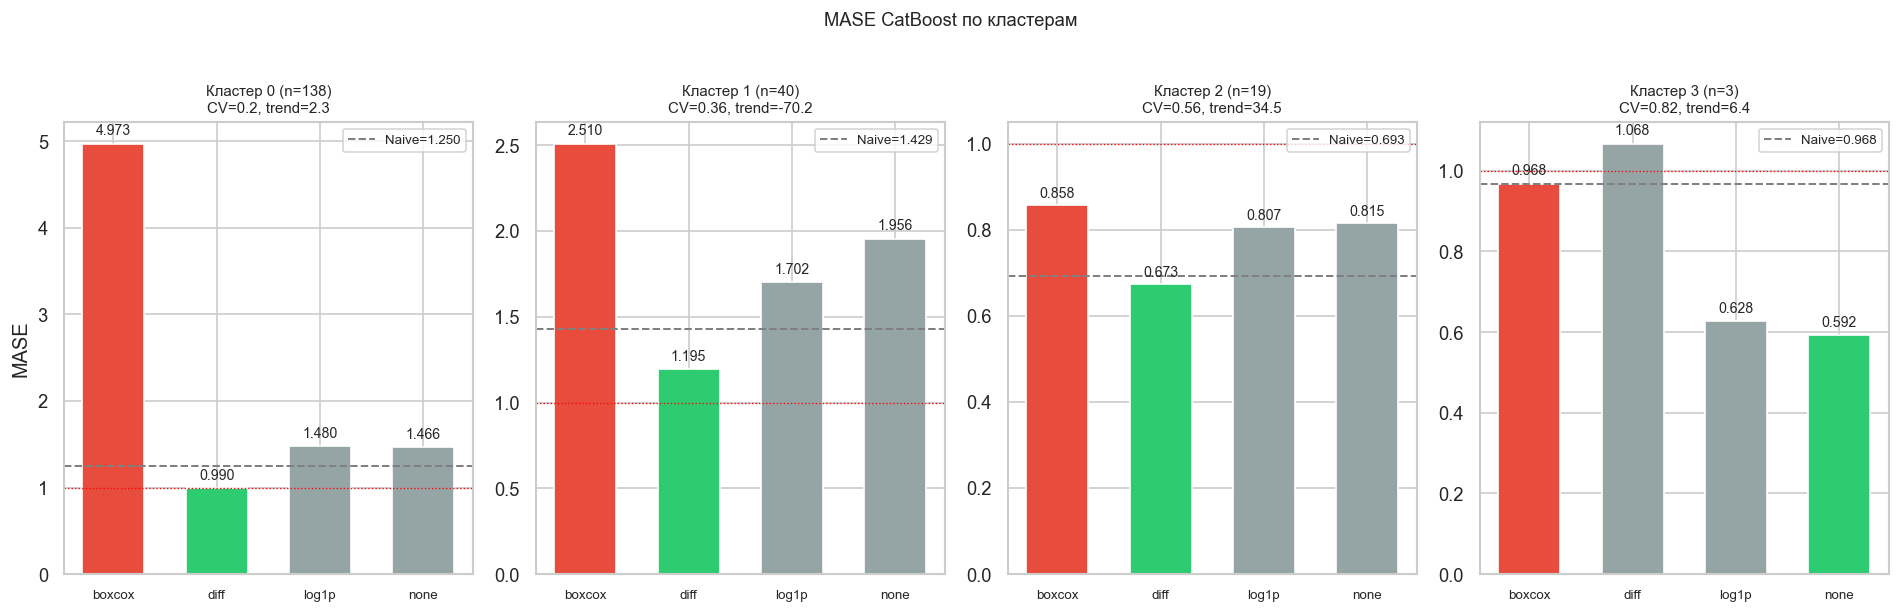

In [28]:
n_clusters_actual = len(mase_pivot)
naive_mase_by_cluster = (
    bd[bd['model']=='naive']
    .groupby('cluster')['MASE'].mean()
    .to_dict()
)

fig, axes = plt.subplots(1, n_clusters_actual, figsize=(4 * n_clusters_actual, 5))
if n_clusters_actual == 1:
    axes = [axes]

for i, c in enumerate(mase_pivot.index):
    vals       = mase_pivot.loc[c]
    bar_colors = [
        '#2ecc71' if v == vals.min() else
        '#e74c3c' if t == 'boxcox'   else '#95a5a6'
        for v, t in zip(vals, vals.index)
    ]
    bars = axes[i].bar(vals.index, vals.values,
                       color=bar_colors, edgecolor='white', width=0.6)
    n_val = n_per_cluster.get(c, '?')
    naive_val = naive_mase_by_cluster.get(c, None)
    if naive_val:
        axes[i].axhline(naive_val, color='gray', ls='--', lw=1.2,
                        label=f'Naive={naive_val:.3f}')
    axes[i].axhline(1.0, color='red', ls=':', lw=0.8)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + float(vals.max()) * 0.02,
                     f'{val:.3f}', ha='center', fontsize=8.5)
    cv_c  = round(float(cluster_stats_cl.loc[c, 'cv']), 2)
    tr_c  = round(float(cluster_stats_cl.loc[c, 'trend']), 1)
    axes[i].set_title(f'Кластер {c} (n={n_val})\nCV={cv_c}, trend={tr_c}', fontsize=9)
    axes[i].set_ylabel('MASE' if i == 0 else '')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', labelsize=8)

plt.suptitle('MASE CatBoost по кластерам',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('cluster_mase_by_transform.png', bbox_inches='tight')
plt.show()

## 8. Аномалия CatBoost + boxcox

In [31]:
cb_global = summary[summary['model'] == 'catboost'].set_index('transform')
best_t    = cb_global['MASE'].idxmin()

print(f'Насколько boxcox хуже лучшей трансформации ({best_t}):')
for metric in ['MAE','RMSE','sMAPE','MASE']:
    ratio = cb_global.loc['boxcox', metric] / cb_global.loc[best_t, metric]
    print(f'  {metric:6s}: boxcox в {ratio:.1f} раза хуже {best_t}')

bx_by_c  = cb_bd[cb_bd['transform']=='boxcox'].set_index('cluster')['MASE']
di_by_c  = cb_bd[cb_bd['transform']==best_t ].set_index('cluster')['MASE']
ku_by_c  = cluster_stats_cl['kurt']
for c in sorted(bx_by_c.index):
    bx = bx_by_c[c]; di = di_by_c.get(c, float('nan'))
    ku = ku_by_c.get(c, float('nan'))
    print(f'  К{c} kurt={ku:.2f}: boxcox MASE={bx:.3f}, {best_t} MASE={di:.3f}')

Насколько boxcox хуже лучшей трансформации (diff):
  MAE   : boxcox в 2.3 раза хуже diff
  RMSE  : boxcox в 2.1 раза хуже diff
  sMAPE : boxcox в 2.9 раза хуже diff
  MASE  : boxcox в 4.0 раза хуже diff
  К0 kurt=-0.25: boxcox MASE=4.973, diff MASE=0.990
  К1 kurt=-0.61: boxcox MASE=2.510, diff MASE=1.195
  К2 kurt=0.43: boxcox MASE=0.858, diff MASE=0.673
  К3 kurt=36.78: boxcox MASE=0.968, diff MASE=1.068


## 9. Детальное сравнение: CatBoost vs AutoTheta vs Naive

In [35]:
# MASE по кластерам для diff-трансформации
comp_data = {
    'cluster': [0, 1, 2, 3],
    'n':       [138, 40, 19, 3],
    'Naive':        [1.250, 1.429, 0.693, 0.968],
    'SeasonalNaive':[1.256, 1.461, 0.933, 1.248],
    'AutoTheta':    [0.974, 1.162, 0.708, 0.625],
    'AutoETS':      [0.909, 1.067, 0.711, 0.981],
    'CatBoost+diff':[0.990, 1.195, 0.673, 1.068],
}
comp_df = pd.DataFrame(comp_data).set_index('cluster')

display(comp_df.drop(columns=['n']).round(3)
        .style.highlight_min(axis=1, color='#c8f0c8'))


,Naive,SeasonalNaive,AutoTheta,AutoETS,CatBoost+diff
cluster,,,,,
0,1.250000,1.256000,0.974000,0.909000,0.990000
1,1.429000,1.461000,1.162000,1.067000,1.195000
2,0.693000,0.933000,0.708000,0.711000,0.673000
3,0.968000,1.248000,0.625000,0.981000,1.068000


## 10. Выводы по гипотезе

| Кластер | Характер | n | Лучшая трансформация | CatBoost MASE |
|---------|----------|---|---------------------|--------------|
| 0 | Стабильные, CV=0.20, без тренда | 138 | **diff** | 0.990 |
| 1 | Растущие, trend=+34, CV=0.56 | 40 | **diff** | 1.195 |
| 2 | Нисходящий тренд, −70/мес | 19 | **diff** | **0.673** |
| 3 | Экстремальные выбросы, kurt=36.8 | 3 | **none** | 0.592 |

### Выводы

**Гипотеза подтверждается: разные типы рядов требуют разных трансформаций.**

1. **`diff` — лучшая трансформация для 3 из 4 кластеров.** Дифференцирование переводит модель из пространства уровней в пространство приращений. Для трендовых рядов (кластеры 1, 2) это физически обоснованно — устраняет нестационарность. Для стабильных рядов (кластер 0) эффект небольшой, но положительный.

2. **Ключевой результат — кластер 2 (нисходящий тренд, n=19).** CatBoost+diff превзошёл. Это единственный кластер, где глобальная ML-модель победила локальные статистические.

3. **`none` лучше для кластера 3 (kurt=36.8, n=3).** При экстремальных выбросах любая трансформация ухудшает результат: `diff` усиливает амплитуду выбросов, `boxcox` взрывается при восстановлении. Деревья CatBoost сами устойчивы к выбросам.

4. **`log1p` — маргинальный эффект** (разница с `none` менее 5%). SeriesScaler уже нормализует масштаб рядов, поэтому дополнительная логарифмическая компрессия не даёт существенного выигрыша.

5. **`boxcox` стабильно вреден для CatBoost** . Это ограничение применения трансформации с ML-моделями, а не свойство самого Box-Cox.
